In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# from utils.utils import *
from utils.data_loader import load_data

# Loading data

In [2]:
final_clean_strained = load_data(db_level=0)

In [3]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)

In [4]:
final_clean_strained = (
    final_clean_strained.groupby(["Subject", "Frequency(kHz)", "Level(dB)"])
    .agg(
        {
            "Amplitude": "mean",
            "SynapsesPerIHC": "mean",
            "IHCs": "mean",
            "OrphansPerIHC": "mean",
            "Waveform": "first",
            "WaveI": "first",
            "Peaks": "first",
            "Troughs": "first",
            "Strain": "first",
            "Sex": "first",
            "Group": "first",
            "Noise": "mean",
            "Time (str)": "first",
            "Time (hrs)": "first",
            "Strain (binary)": "first",
            "PeakI Left Curvature": "first",
            "PeakI Overall Curvature": "first",
            "PeakI Right Curvature": "first",
            "TroughI Left Curvature": "first",
            "TroughI Overall Curvature": "first",
            "TroughI Right Curvature": "first",
            "Slope": "first",
            "Distance": "first",
            "Total Variance": "first",
        }
    )
    .reset_index()
)

In [5]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

In [6]:
pd.DataFrame(
    [
        x[1]
        for x in final_clean_strained.groupby("Subject")["Noise"]
        .value_counts()
        .index.values
    ]
).value_counts()

0   
0.00    33
0.98    27
0.94    25
0.90    17
1.01     3
Name: count, dtype: int64

# Train test split

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    cat_features,
    log_features,
    minmax_features,
    target="SynapsesPerIHC",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
            ("log_transform", log_scale_pipeline, log_features),
            ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor

In [17]:
final_clean_strained_80 = final_clean_strained[
    (final_clean_strained["Level(dB)"] == 80)
    # & (
    #     (final_clean_strained["Frequency(kHz)"] == 16.0)
    #     | (final_clean_strained["Frequency(kHz)"] == 32.0)
    # )
]
final_clean_strained_80["Amplitude"].describe()

count    616.000000
mean       1.274205
std        0.775082
min        0.000000
25%        0.657268
50%        1.258401
75%        1.793453
max        3.799152
Name: Amplitude, dtype: float64

In [18]:
import statsmodels.api as sm

formula = 'SynapsesPerIHC~Q("Amplitude")'
model = sm.OLS.from_formula(formula, data=final_clean_strained_80)
fit = model.fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     94.75
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           6.40e-21
Time:                        19:16:23   Log-Likelihood:                -1570.3
No. Observations:                 616   AIC:                             3145.
Df Residuals:                     614   BIC:                             3154.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         12.8600      0.241     53.

In [8]:
final_clean_strained_70 = final_clean_strained[final_clean_strained["Level(dB)"] == 70]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Noise", "Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70, num_features, cat_features, log_features, minmax_features
)

# Vanilla Linear Regression

In [9]:
smf_df = final_clean_strained_70.copy()
smf_df.columns = [
    "Subject",
    "Frequency",
    "Level",
    "Amplitude",
    "SynapsesPerIHC",
    "IHCs",
    "OrphansPerIHC",
    "Waveform",
    "WaveI",
    "Peaks",
    "Troughs",
    "Strain",
    "Sex",
    "Group",
    "Noise",
    "Time(str)",
    "Time_hrs",
    "Strain_b",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
    "Slope",
    "Distance",
    "TotalVariance",
    "DataGroup",
]

In [10]:
import statsmodels.formula.api as smf


def VIF(reg: str):
    vif_model = smf.ols(reg, data=smf_df).fit()
    r2j = vif_model.rsquared
    vif_j = 1 / (1 - r2j)
    return vif_j


features = [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Noise",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

for feature in features:
    reg = f"{feature} ~ "
    for i in features:
        if i != feature:
            reg += i + " + "
    print(f"VIF for {feature}: {VIF(reg[:-3]):.5f}")

VIF for Frequency: 1.17470
VIF for Amplitude: 22.91368
VIF for Slope: 11.16521
VIF for TotalVariance: 10.68441
VIF for Distance: 1.13683
VIF for Noise: 1.96579
VIF for Time_hrs: 1.93412
VIF for PeakILeftCurvature: 1.49144
VIF for PeakIOverallCurvature: 1.07939
VIF for PeakIRightCurvature: 1.70586
VIF for TroughILeftCurvature: 1.41470
VIF for TroughIOverallCurvature: 1.09423
VIF for TroughIRightCurvature: 1.11491


In [11]:
features = [
    "Frequency",
    "Amplitude",
    # "Slope",
    "TotalVariance",
    "Distance",
    "Noise",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

for feature in features:
    reg = f"{feature} ~ "
    for i in features:
        if i != feature:
            reg += i + " + "
    print(f"VIF for {feature}: {VIF(reg[:-3]):.5f}")

VIF for Frequency: 1.16790
VIF for Amplitude: 14.91356
VIF for TotalVariance: 10.59348
VIF for Distance: 1.09642
VIF for Noise: 1.96519
VIF for Time_hrs: 1.91522
VIF for PeakILeftCurvature: 1.49135
VIF for PeakIOverallCurvature: 1.07201
VIF for PeakIRightCurvature: 1.67185
VIF for TroughILeftCurvature: 1.40742
VIF for TroughIOverallCurvature: 1.09413
VIF for TroughIRightCurvature: 1.11487


In [12]:
model_text = "SynapsesPerIHC ~ C(Strain_b)"

for feature in features:
    model_text += f" + {feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     23.67
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           4.45e-46
Time:                        19:33:45   Log-Likelihood:                -1487.4
No. Observations:                 616   AIC:                             3003.
Df Residuals:                     602   BIC:                             3065.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  16.6100      0.815     20.386      0.000      15.010      18.210
C(Strain_b)[T.1]            1.3210      0.316      4.186      0.000       0.701       1.941
Frequency                  -0.0246      0.009     -2.630      0.009      -0.043      -0.006
Amplitude                   2.0552      0.729      2.820      0.005       0.624       3.487
TotalVariance              -0.2241      0.094     -2.392      0.017      -0.408      -0.040
Distance                   -1.2762      0.536     -2.380      0.018      -2.329      -0.223
Noise                      -2.5049      0.359     -6.981      0.000      -3.210      -1.800
Time_hrs                   -0.0156      0.005     -3.257      0.001      -0.025      -0.006
PeakILeftCurvature         -0.0037      0.015     -0.244      0.808      -0.033       0.026
PeakIOverallCurvature      -0.0006      0.005     -0.137      0.891      -0.010       0.008
PeakIRightCurvature        -0.0863      0.016     -5.288      0.000      -0.118      -0.054
TroughILeftCurvature       -0.0205      0.011     -1.794      0.073      -0.043       0.002
TroughIOverallCurvature    -0.0019      0.005     -0.405      0.685      -0.011       0.007
TroughIRightCurvature      -0.0034      0.009     -0.389      0.697      -0.020       0.014
==============================================================================
Omnibus:                       40.767   Durbin-Watson:                   1.385
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               57.891
Skew:                          -0.525   Prob(JB):                     2.69e-13
Kurtosis:                       4.073   Cond. No.                         648.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Linear Regression w/ Interaction Terms

In [13]:
model_text = "SynapsesPerIHC ~ C(Strain_b)"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + Noise:{feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.370
Method:                 Least Squares   F-statistic:                     28.73
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           6.74e-55
Time:                        19:33:46   Log-Likelihood:                -1465.9
No. Observations:                 616   AIC:                             2960.
Df Residuals:                     602   BIC:                             3022.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        15.0941      0.317     47.564      0.000      14.471      15.717
C(Strain_b)[T.1]                  1.5254      0.299      5.099      0.000       0.938       2.113
Noise:Frequency                  -0.0629      0.011     -5.945      0.000      -0.084      -0.042
Noise:Amplitude                   1.1574      1.094      1.058      0.291      -0.991       3.306
Noise:Slope                      -0.5152      0.354     -1.454      0.146      -1.211       0.181
Noise:TotalVariance              -0.2975      0.102     -2.913      0.004      -0.498      -0.097
Noise:Distance                   -1.3806      0.514     -2.686      0.007      -2.390      -0.371
Noise:Time_hrs                   -0.0193      0.006     -3.164      0.002      -0.031      -0.007
Noise:PeakILeftCurvature          0.0008      0.016      0.050      0.960      -0.030       0.032
Noise:PeakIOverallCurvature      -0.0021      0.006     -0.343      0.731      -0.014       0.010
Noise:PeakIRightCurvature        -0.1003      0.018     -5.612      0.000      -0.135      -0.065
Noise:TroughILeftCurvature       -0.0347      0.013     -2.765      0.006      -0.059      -0.010
Noise:TroughIOverallCurvature    -0.0049      0.006     -0.807      0.420      -0.017       0.007
Noise:TroughIRightCurvature       0.0106      0.011      0.932      0.352      -0.012       0.033
==============================================================================
Omnibus:                       35.131   Durbin-Watson:                   1.478
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.844
Skew:                          -0.441   Prob(JB):                     2.03e-12
Kurtosis:                       4.149   Cond. No.                         522.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
model_text = "SynapsesPerIHC ~ C(Strain_b)"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + Noise*{feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     14.95
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           2.90e-49
Time:                        19:33:46   Log-Likelihood:                -1458.5
No. Observations:                 616   AIC:                             2971.
Df Residuals:                     589   BIC:                             3090.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        12.3287      1.924      6.409      0.000       8.551      16.107
C(Strain_b)[T.1]                  1.4603      0.310      4.709      0.000       0.851       2.069
Noise                             2.3474      2.090      1.123      0.262      -1.758       6.453
Frequency                         0.0246      0.015      1.588      0.113      -0.006       0.055
Noise:Frequency                  -0.0840      0.020     -4.129      0.000      -0.124      -0.044
Amplitude                        -0.3307      1.558     -0.212      0.832      -3.390       2.729
Noise:Amplitude                   1.9291      2.043      0.944      0.345      -2.083       5.941
Slope                            -0.6353      0.418     -1.520      0.129      -1.456       0.186
Noise:Slope                       0.1287      0.565      0.228      0.820      -0.982       1.239
TotalVariance                    -0.0845      0.172     -0.491      0.624      -0.423       0.254
Noise:TotalVariance              -0.2620      0.219     -1.195      0.233      -0.693       0.169
Distance                          5.5083      3.069      1.795      0.073      -0.519      11.535
Noise:Distance                   -6.9189      3.247     -2.131      0.033     -13.295      -0.543
Time_hrs                         -0.0163      0.008     -1.976      0.049      -0.032   -9.87e-05
Noise:Time_hrs                   -0.0019      0.011     -0.179      0.858      -0.023       0.019
PeakILeftCurvature                0.0135      0.038      0.355      0.722      -0.061       0.088
Noise:PeakILeftCurvature         -0.0088      0.043     -0.205      0.838      -0.093       0.075
PeakIOverallCurvature            -0.0003      0.007     -0.045      0.964      -0.015       0.014
Noise:PeakIOverallCurvature      -0.0011      0.010     -0.108      0.914      -0.020       0.018
PeakIRightCurvature               0.0032      0.041      0.079      0.937      -0.078       0.084
Noise:PeakIRightCurvature        -0.1001      0.047     -2.143      0.032      -0.192      -0.008
TroughILeftCurvature              0.0142      0.029      0.485      0.628      -0.043       0.072
Noise:TroughILeftCurvature       -0.0470      0.033     -1.403      0.161      -0.113       0.019
TroughIOverallCurvature          -0.0008      0.007     -0.110      0.913      -0.014       0.013
Noise:TroughIOverallCurvature    -0.0034      0.010     -0.353      0.724      -0.022       0.015
TroughIRightCurvature            -0.0032      0.014     -0.238      0.812      -0.030       0.023
Noise:TroughIRightCurvature       0.0152      0.018      0.827      0.408      -0.021       0.051
==============================================================================
Omnibus:                       33.745   Durbin-Watson:          

In [15]:
model_text = "SynapsesPerIHC ~ C(Strain_b) + Noise:Frequency"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "Noise",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + {feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     23.47
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           8.31e-51
Time:                        19:33:46   Log-Likelihood:                -1472.3
No. Observations:                 616   AIC:                             2977.
Df Residuals:                     600   BIC:                             3047.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  15.2627      0.834     18.298      0.000      13.625      16.901
C(Strain_b)[T.1]            1.2942      0.309      4.194      0.000       0.688       1.900
Noise:Frequency            -0.1036      0.020     -5.302      0.000      -0.142      -0.065
Frequency                   0.0378      0.015      2.505      0.012       0.008       0.067
Amplitude                   1.0231      0.885      1.156      0.248      -0.715       2.761
Slope                      -0.3798      0.252     -1.506      0.133      -0.875       0.115
Noise                      -0.2457      0.551     -0.446      0.656      -1.327       0.836
TotalVariance              -0.2157      0.092     -2.342      0.019      -0.396      -0.035
Distance                   -1.0425      0.534     -1.952      0.051      -2.091       0.006
Time_hrs                   -0.0152      0.005     -3.223      0.001      -0.024      -0.006
PeakILeftCurvature          0.0007      0.015      0.047      0.963      -0.028       0.030
PeakIOverallCurvature      -0.0014      0.005     -0.303      0.762      -0.010       0.008
PeakIRightCurvature        -0.0821      0.016     -5.090      0.000      -0.114      -0.050
TroughILeftCurvature       -0.0229      0.011     -2.040      0.042      -0.045      -0.001
TroughIOverallCurvature    -0.0032      0.004     -0.719      0.472      -0.012       0.006
TroughIRightCurvature      -0.0008      0.008     -0.094      0.925      -0.017       0.016
==============================================================================
Omnibus:                       35.310   Durbin-Watson:                   1.449
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               50.122
Skew:                          -0.470   Prob(JB):                     1.31e-11
Kurtosis:                       4.035   Cond. No.                         692.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Elastic Net

In [16]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", ElasticNetCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10], cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Elastic Net training set score: {pipeline.score(X_train, y_train)}")
print(f"Elastic Net test set score: {pipeline.score(X_test, y_test)}")

Elastic Net training set score: 0.283887319743077
Elastic Net test set score: 0.23980488799232325


In [17]:
features = X_train.columns
coefs = pipeline.named_steps["elasticnet_cv"].coef_
count = len(coefs[coefs != 0])
print(f"{count} features were selected")
print(f"Dropped features: {features[coefs == 0].values}")

11 features were selected
Dropped features: ['Level(dB)' 'Total Variance' 'PeakI Overall Curvature' 'Time (hrs)']


# Random Forest

In [18]:
rf_params = {
    "rf__n_estimators": [25, 30, 50, 100, 150, 200, 300, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 150, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 'log2', 'rf__max_depth': 30}
Best RF score: 0.434, R2 on test set: 0.463


# Feature Importance

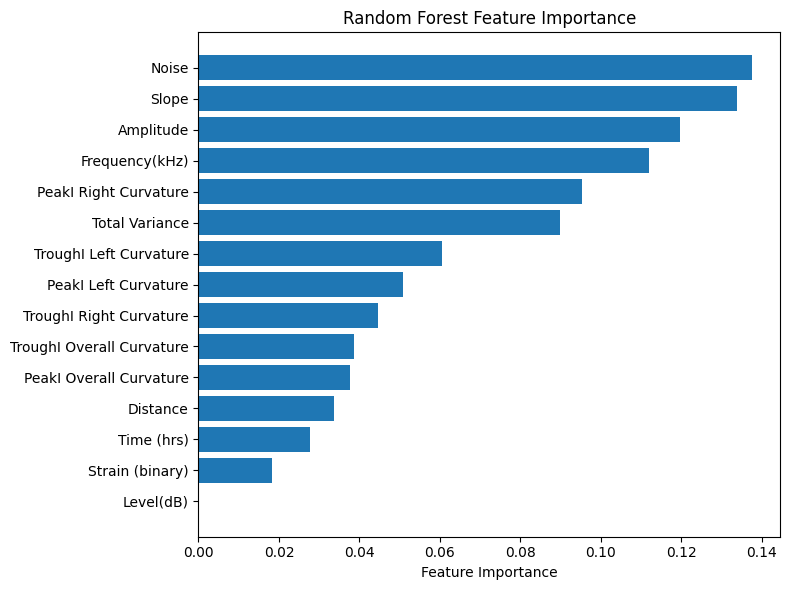

In [19]:
best_rf_model = rf_search.best_estimator_
feature_importance = best_rf_model.named_steps["rf"].feature_importances_
feature_names = best_rf_model.feature_names_in_

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(range(len(importance_df)), importance_df["Importance"])
plt.yticks(range(len(importance_df)), importance_df["Feature"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Permutation Importance


Permutation Importance Rankings:
                      Feature  Importance_Mean  Importance_Std
13                      Noise         0.244325        0.057980
5              Frequency(kHz)         0.220368        0.048936
9       PeakI Right Curvature         0.027955        0.019465
4             Strain (binary)         0.020635        0.005442
10     TroughI Left Curvature         0.014268        0.009227
12    TroughI Right Curvature         0.008470        0.004675
14                 Time (hrs)         0.008212        0.009564
7        PeakI Left Curvature         0.002265        0.009293
8     PeakI Overall Curvature         0.001967        0.005350
3                   Level(dB)         0.000000        0.000000
2                    Distance        -0.002144        0.004647
11  TroughI Overall Curvature        -0.004146        0.006141
0                   Amplitude        -0.017219        0.016832
6              Total Variance        -0.017314        0.011187
1                    

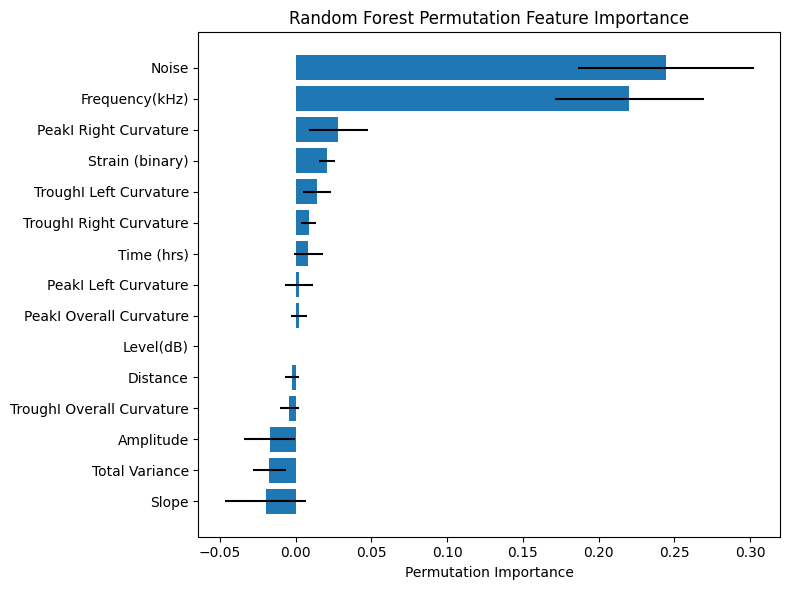

In [20]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
)
perm_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance_Mean": perm_importance.importances_mean,
        "Importance_Std": perm_importance.importances_std,
    }
).sort_values("Importance_Mean", ascending=False)

print("\nPermutation Importance Rankings:")
print(perm_importance_df)

# Plot permutation importance with error bars
plt.figure(figsize=(8, 6))
plt.barh(
    range(len(perm_importance_df)),
    perm_importance_df["Importance_Mean"],
    xerr=perm_importance_df["Importance_Std"],
)
plt.yticks(range(len(perm_importance_df)), perm_importance_df["Feature"])
plt.xlabel("Permutation Importance")
plt.title("Random Forest Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# SHAP

[Text(0, 0, 'Level(dB)'), Text(0, 1, 'PeakI Overall Curvature'), Text(0, 2, 'Distance'), Text(0, 3, 'TroughI Overall Curvature'), Text(0, 4, 'TroughI Right Curvature'), Text(0, 5, 'TroughI Left Curvature'), Text(0, 6, 'PeakI Left Curvature'), Text(0, 7, 'Time (hrs)'), Text(0, 8, 'Strain (binary)'), Text(0, 9, 'Total Variance'), Text(0, 10, 'PeakI Right Curvature'), Text(0, 11, 'Amplitude'), Text(0, 12, 'Frequency(kHz)'), Text(0, 13, 'Slope'), Text(0, 14, 'Noise')]


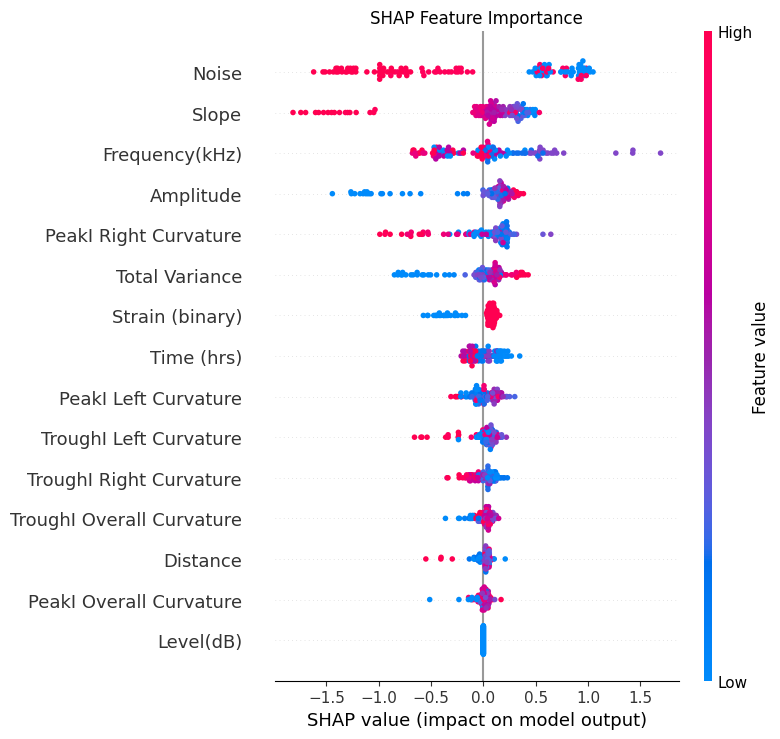

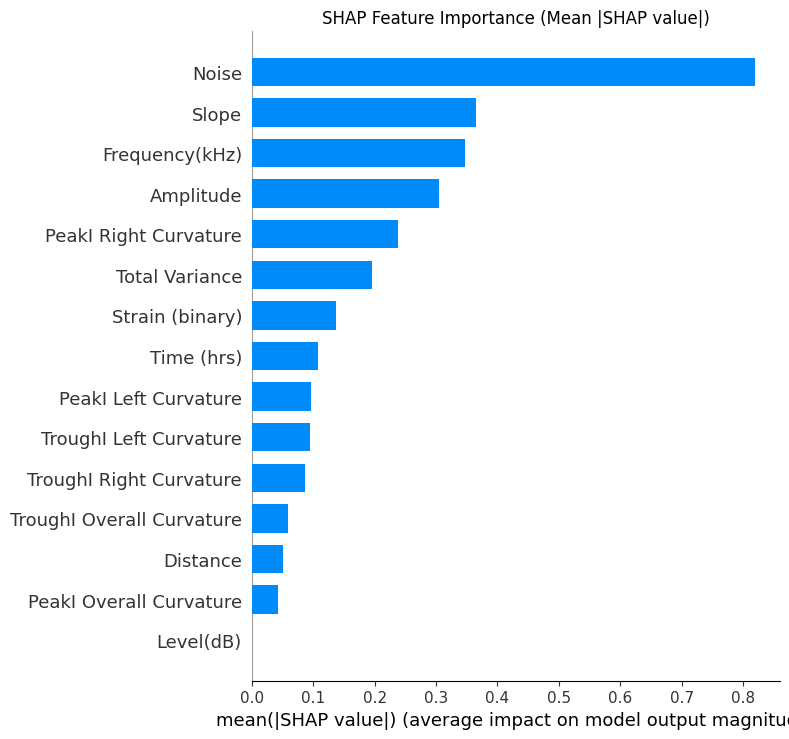

In [21]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(best_rf_model.named_steps["rf"])

# Get preprocessed test data
X_test_preprocessed = best_rf_model.named_steps["preprocessor"].transform(X_test)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_preprocessed)

# Summary plot
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values, X_test_preprocessed, feature_names=feature_names, show=False
)
plt.title("SHAP Feature Importance")
print(plt.gca().get_yticklabels())
# plt.gca().set_yticklabels(feature_names, rotation=45)
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values,
    X_test_preprocessed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()

In [22]:
shap_interaction_values = explainer.shap_interaction_values(X_test_preprocessed)

In [23]:
def plot_shap_dependence(ft1, ft2):
    top_features = importance_df["Feature"].values
    feature_idx1 = list(feature_names).index(top_features[ft1])
    feature_idx2 = list(feature_names).index(top_features[ft2])

    # Main effects and interaction using shap.dependence_plot
    shap.dependence_plot(
        feature_idx1,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft1]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        feature_idx2,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft2]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        (feature_idx1, feature_idx2),
        shap_interaction_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
        interaction_index=feature_idx2,
    )
    plt.title(f"{top_features[ft1]} x {top_features[ft2]} Interaction")

    plt.tight_layout()
    plt.show()

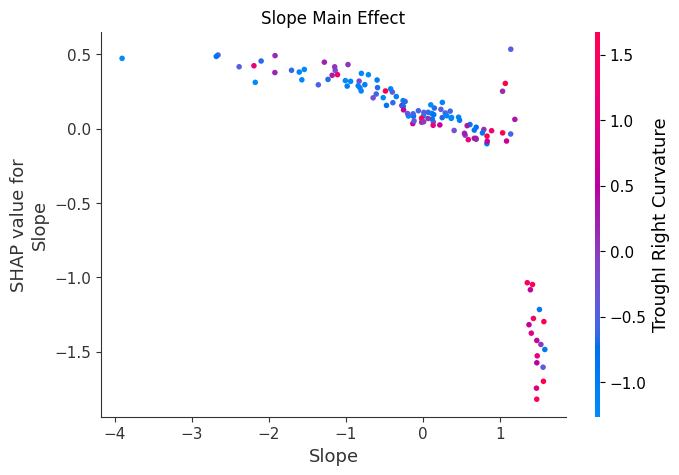

<Figure size 300x300 with 0 Axes>

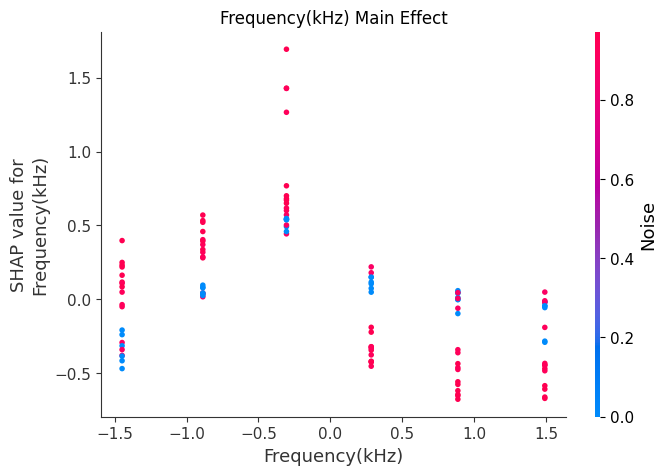

<Figure size 300x300 with 0 Axes>

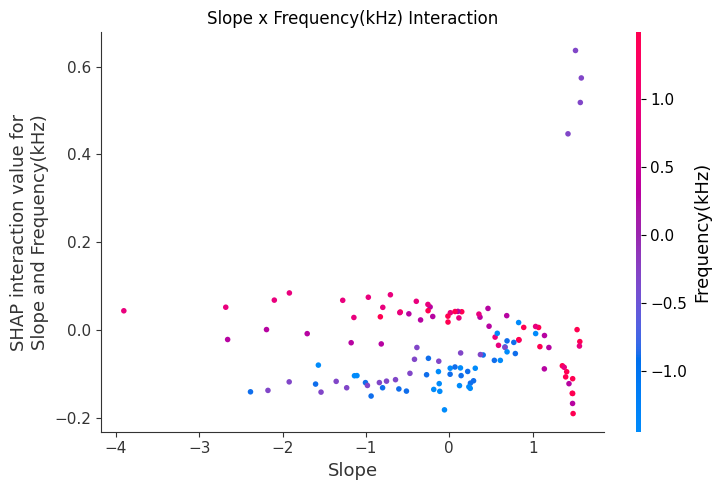

In [24]:
plot_shap_dependence(1, 3)

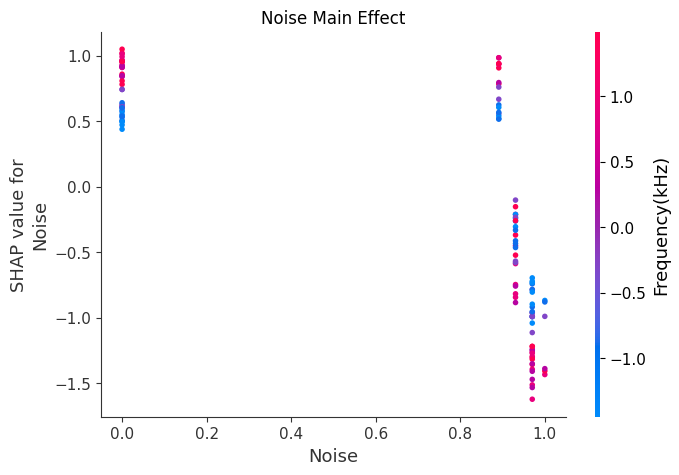

<Figure size 300x300 with 0 Axes>

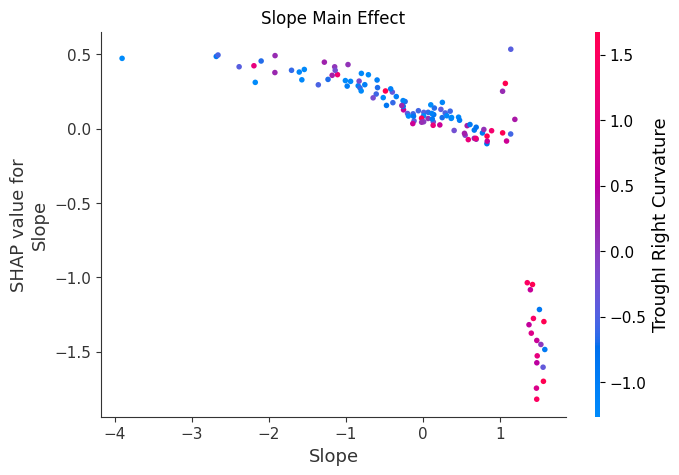

<Figure size 300x300 with 0 Axes>

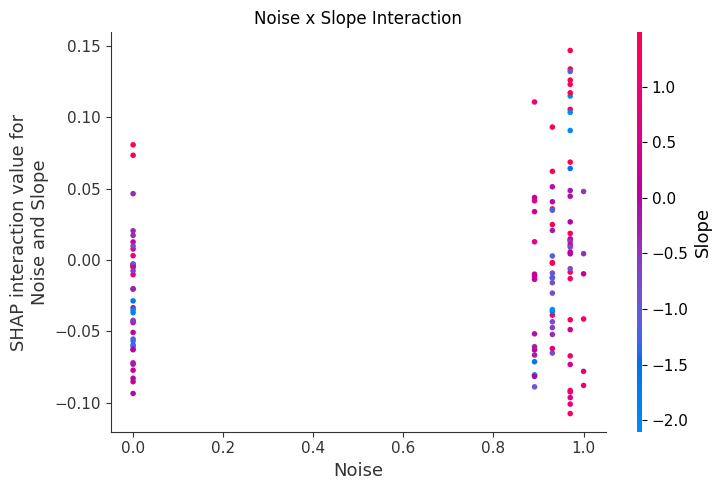

In [25]:
plot_shap_dependence(0, 1)

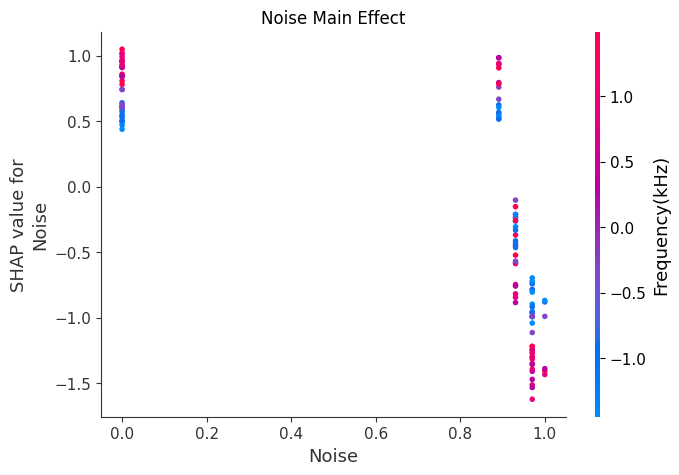

<Figure size 300x300 with 0 Axes>

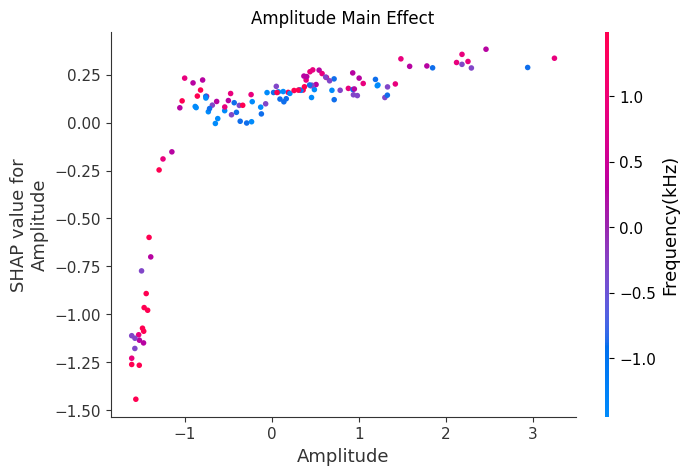

<Figure size 300x300 with 0 Axes>

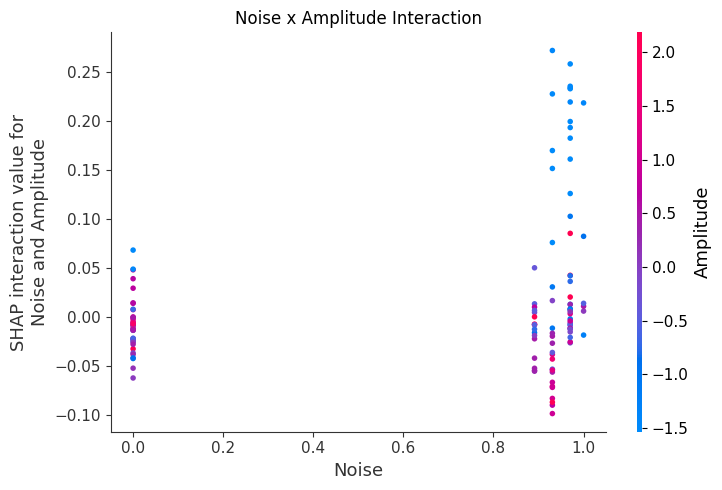

In [26]:
plot_shap_dependence(0, 2)

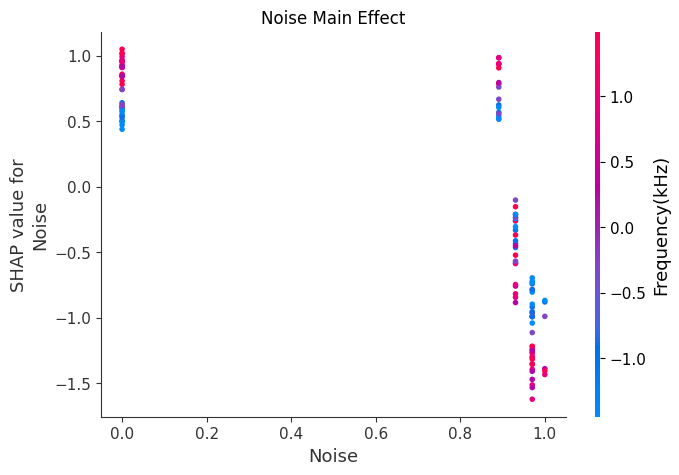

<Figure size 300x300 with 0 Axes>

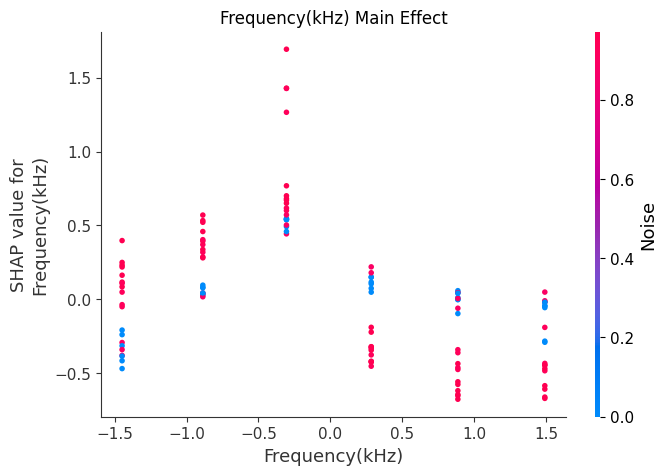

<Figure size 300x300 with 0 Axes>

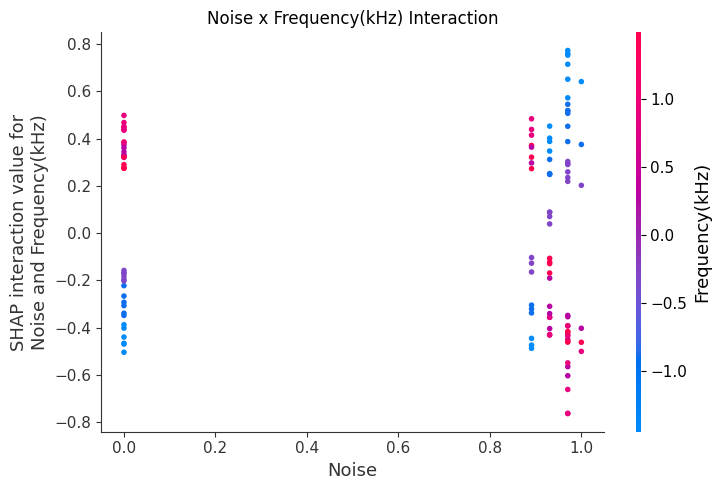

In [27]:
plot_shap_dependence(0, 3)

In [28]:
def plot_results(x, y, alpha=0.2, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")

In [29]:
def train_plot_result(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    dB_bins = [10, 20, 30, 40, 50, 60, 70, 80]
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(dB_bins) + 2)
    # iterate over dB levels:
    for dB in dB_bins:
        features = num_features + cat_features + log_features + minmax_features
        data = df[(df["Level(dB)"] >= dB) & (df["Level(dB)"] < dB + 10)]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(
                f"{dB}-{dB + 5} dB, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}"
            )
            plt.subplot(2, 5, dB // 10)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{dB}-{dB + 5} dB",
                color=color_palette(dB // 10 - 1),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 5, 9)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

In [30]:
def train_plot_result_frequency(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

10-15 dB, 542 samples, R2: 0.234, RMSE: 1.723
20-25 dB, 870 samples, R2: 0.488, RMSE: 1.610
30-35 dB, 907 samples, R2: 0.486, RMSE: 1.701
40-45 dB, 802 samples, R2: 0.416, RMSE: 1.936
50-55 dB, 721 samples, R2: 0.468, RMSE: 2.114
60-65 dB, 719 samples, R2: 0.470, RMSE: 2.244
70-75 dB, 724 samples, R2: 0.576, RMSE: 2.410
80-85 dB, 616 samples, R2: 0.541, RMSE: 2.231
All data, 5901 samples, R2: 0.626, RMSE: 1.743


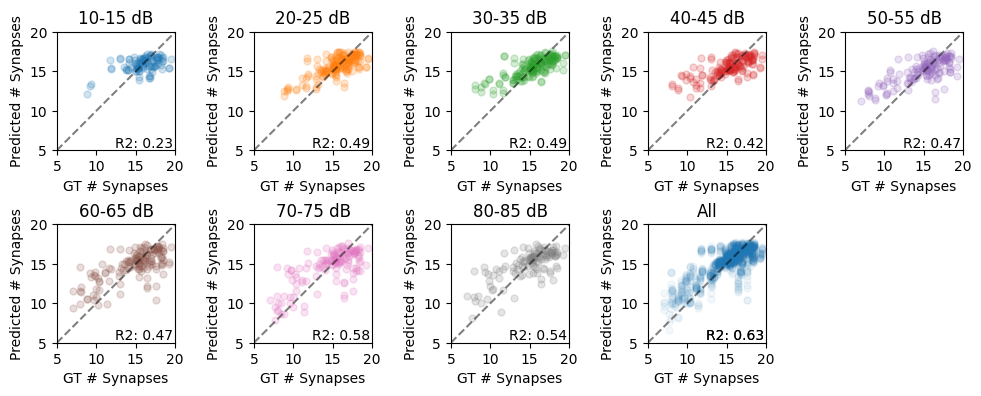

In [31]:
train_plot_result(final_clean_strained, best_rf_model)

8.0Hz, 1043 samples, R2: 0.567, RMSE: 0.899
11.3Hz, 1009 samples, R2: 0.417, RMSE: 0.839
16.0Hz, 979 samples, R2: -0.005, RMSE: 1.470
22.6Hz, 953 samples, R2: 0.586, RMSE: 2.149
32.0Hz, 947 samples, R2: 0.712, RMSE: 1.998
45.2Hz, 970 samples, R2: 0.741, RMSE: 1.839
All data, 5901 samples, R2: 0.626, RMSE: 1.743


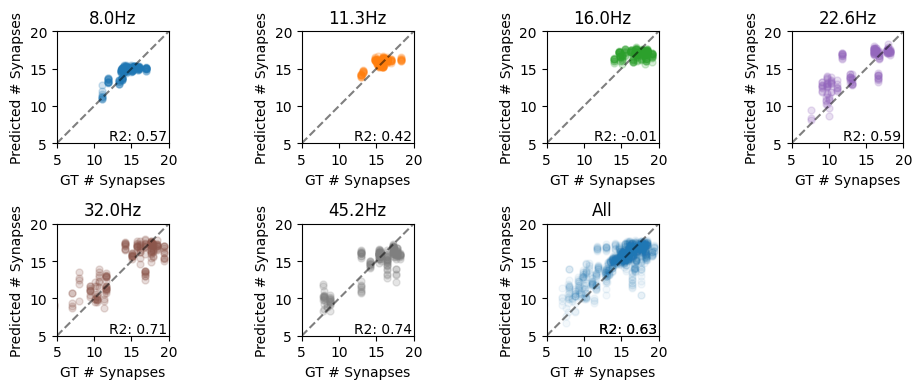

In [32]:
train_plot_result_frequency(final_clean_strained, best_rf_model)

In [33]:
from sklearn.metrics import r2_score


def train_plot_result_frequency_grouped(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            test = data[data.DataGroup == "Test"].copy()
            test["preds"] = rf_pipeline.predict(X_test1)
            grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
                {"SynapsesPerIHC": "mean", "preds": "mean"}
            )
            r2 = r2_score(grouped_preds["SynapsesPerIHC"], grouped_preds["preds"])
            rmse = np.sqrt(
                np.mean((grouped_preds["SynapsesPerIHC"] - grouped_preds["preds"]) ** 2)
            )
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                grouped_preds["SynapsesPerIHC"],
                grouped_preds["preds"],
                title=f"{frq}Hz",
                color=color_palette(i),
                alpha=0.5,
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    test = df[df.DataGroup == "Test"].copy()
    test["preds"] = rf_pipeline.predict(X_test)
    grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
        {"SynapsesPerIHC": "mean", "preds": "mean"}
    )
    r2 = r2_score(grouped_preds["SynapsesPerIHC"], grouped_preds["preds"])
    rmse = np.sqrt(
        np.mean((grouped_preds["SynapsesPerIHC"] - grouped_preds["preds"]) ** 2)
    )
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        grouped_preds["SynapsesPerIHC"],
        grouped_preds["preds"],
        alpha=0.25,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 1043 samples, R2: 0.614, RMSE: 0.825
11.3Hz, 1009 samples, R2: 0.440, RMSE: 0.847
16.0Hz, 979 samples, R2: 0.046, RMSE: 1.432
22.6Hz, 953 samples, R2: 0.650, RMSE: 2.053
32.0Hz, 947 samples, R2: 0.737, RMSE: 2.121
45.2Hz, 970 samples, R2: 0.792, RMSE: 2.014
All data, 5901 samples, R2: 0.701, RMSE: 1.800


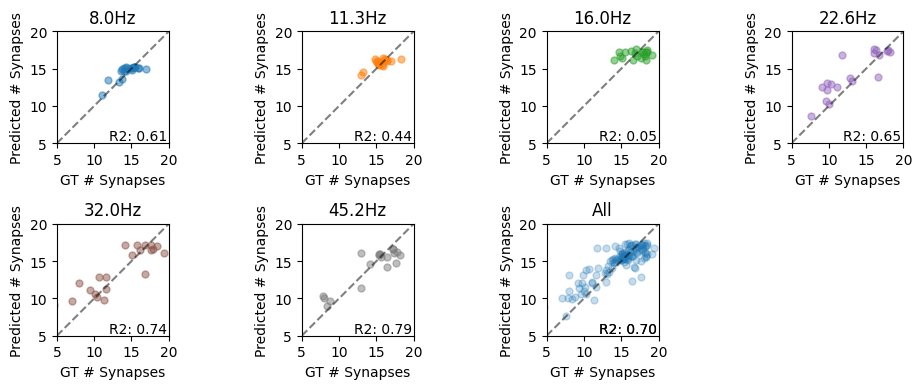

In [34]:
train_plot_result_frequency_grouped(final_clean_strained, best_rf_model)

Best RF score: 0.691, R2 on test set: 0.477
10-15 dB, 542 samples, R2: 0.174, RMSE: 1.790
20-25 dB, 870 samples, R2: 0.533, RMSE: 1.539
30-35 dB, 907 samples, R2: 0.556, RMSE: 1.582
40-45 dB, 802 samples, R2: 0.513, RMSE: 1.768
50-55 dB, 721 samples, R2: 0.524, RMSE: 2.000
60-65 dB, 719 samples, R2: 0.518, RMSE: 2.142
70-75 dB, 724 samples, R2: 0.625, RMSE: 2.267
80-85 dB, 616 samples, R2: 0.584, RMSE: 2.125
All data, 5901 samples, R2: 0.697, RMSE: 1.570


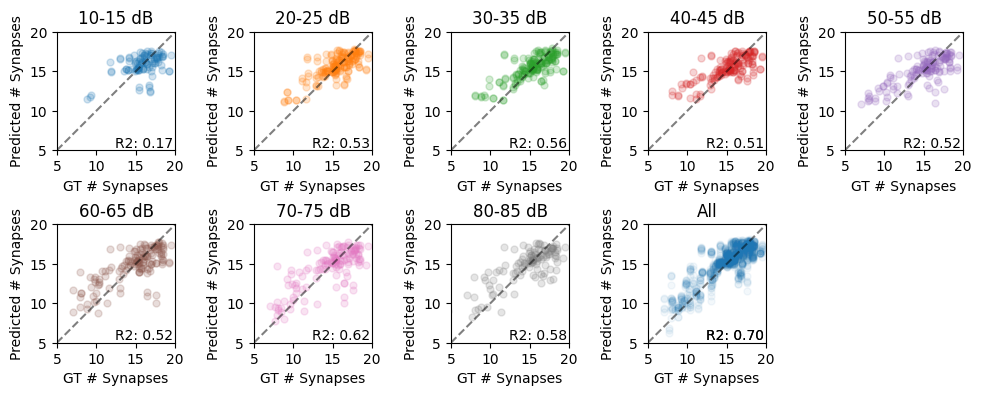

In [35]:
# Deeper trees
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                random_state=1,
                n_estimators=50,
                min_samples_split=30,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=30,
            ),
        ),
    ]
)
rf_pipeline.fit(X_train, y_train)
r2 = rf_pipeline.score(X_test, y_test)
print(
    f"Best RF score: {rf_pipeline.score(X_train, y_train):.3f}, R2 on test set: {r2:.3f}"
)
train_plot_result(final_clean_strained, rf_pipeline)

8.0Hz, 1043 samples, R2: 0.562, RMSE: 0.905
11.3Hz, 1009 samples, R2: 0.470, RMSE: 0.799
16.0Hz, 979 samples, R2: -0.039, RMSE: 1.495
22.6Hz, 953 samples, R2: 0.597, RMSE: 2.120
32.0Hz, 947 samples, R2: 0.739, RMSE: 1.904
45.2Hz, 970 samples, R2: 0.765, RMSE: 1.755
All data, 5901 samples, R2: 0.697, RMSE: 1.570


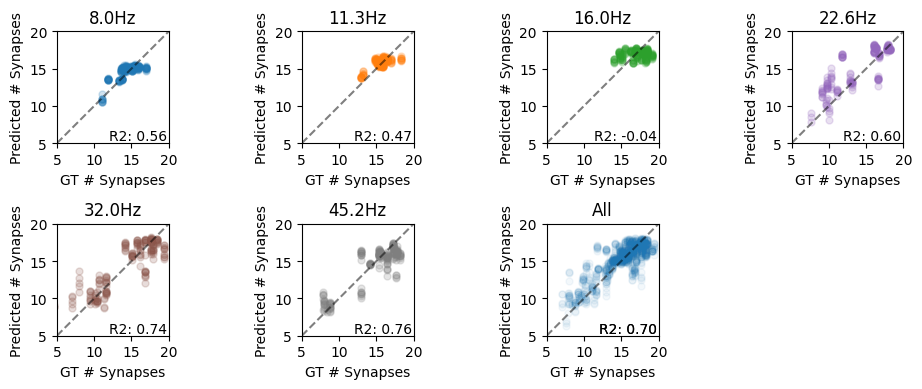

In [36]:
train_plot_result_frequency(final_clean_strained, rf_pipeline)

8.0Hz, 1043 samples, R2: 0.597, RMSE: 0.843
11.3Hz, 1009 samples, R2: 0.495, RMSE: 0.804
16.0Hz, 979 samples, R2: 0.005, RMSE: 1.463
22.6Hz, 953 samples, R2: 0.665, RMSE: 2.009
32.0Hz, 947 samples, R2: 0.751, RMSE: 2.064
45.2Hz, 970 samples, R2: 0.803, RMSE: 1.959
All data, 5901 samples, R2: 0.766, RMSE: 1.594


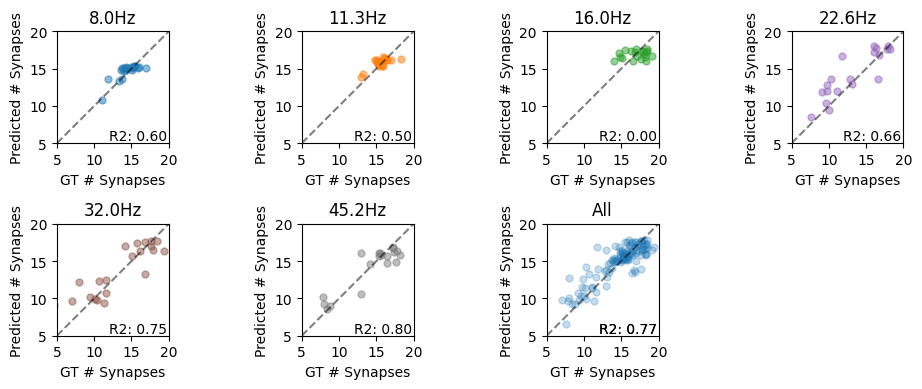

In [37]:
train_plot_result_frequency_grouped(final_clean_strained, rf_pipeline)

In [38]:
import plotly.graph_objects as go

plot_features = num_features + log_features + minmax_features
n_predictors = len(plot_features)

fig = go.Figure()

for i, predictor in enumerate(plot_features):
    x_vals = np.linspace(
        final_clean_strained_70[predictor].min(),
        final_clean_strained_70[predictor].max(),
        100,
    )

    fig.add_trace(
        go.Scatter(
            x=final_clean_strained_70[predictor],
            y=final_clean_strained_70["SynapsesPerIHC"],
            mode="markers",
            name="SynapsesPerIHC",
            visible=(i == 0),
            marker=dict(color="lightgrey"),
            hovertemplate=f"{predictor}<br>SynapsesPerIHC",
        )
    )

buttons = []
for i, predictor in enumerate(plot_features):
    n = 1
    visible = [False] * n_predictors * n
    visible[i * n : i * n + n] = [True] * n

    buttons.append(
        dict(
            label=predictor.lower(),
            method="update",
            args=[
                {"visible": visible},
                {
                    "title": f"SynapsesPerIHC vs {predictor}",
                    "xaxis": {"title": predictor},
                    "yaxis": {"title": "SynapsesPerIHC"},
                },
            ],
        )
    )


fig.update_layout(
    updatemenus=[
        dict(active=0, buttons=buttons, x=1.05, y=1, xanchor="right", yanchor="top")
    ],
    title=f"SynapsesPerIHC vs {plot_features[0]}",
    xaxis_title=plot_features[0],
    yaxis_title="SynapsesPerIHC",
    legend=dict(
        x=0.02,
        y=0.999,
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="black",
        borderwidth=1,
    ),
    width=900,
    height=600,
)

fig.show()

In [39]:
import plotly.graph_objects as go

plot_features = num_features + log_features + minmax_features
n_predictors = len(plot_features)

fig = go.Figure()

for i, predictor in enumerate(plot_features):
    x_vals = np.linspace(
        final_clean_strained_70[predictor].min(),
        final_clean_strained_70[predictor].max(),
        100,
    )

    fig.add_trace(
        go.Scatter(
            x=np.log(np.abs(final_clean_strained_70[predictor])),
            y=final_clean_strained_70["SynapsesPerIHC"],
            mode="markers",
            name="SynapsesPerIHC",
            visible=(i == 0),
            marker=dict(color="lightgrey"),
            hovertemplate=f"{predictor}<br>SynapsesPerIHC",
        )
    )

buttons = []
for i, predictor in enumerate(plot_features):
    n = 1
    visible = [False] * n_predictors * n
    visible[i * n : i * n + n] = [True] * n

    buttons.append(
        dict(
            label=predictor.lower(),
            method="update",
            args=[
                {"visible": visible},
                {
                    "title": f"SynapsesPerIHC vs {predictor}",
                    "xaxis": {"title": predictor},
                    "yaxis": {"title": "SynapsesPerIHC"},
                },
            ],
        )
    )


fig.update_layout(
    updatemenus=[
        dict(active=0, buttons=buttons, x=1.05, y=1, xanchor="right", yanchor="top")
    ],
    title=f"SynapsesPerIHC vs {plot_features[0]}",
    xaxis_title=plot_features[0],
    yaxis_title="SynapsesPerIHC",
    legend=dict(
        x=0.02,
        y=0.999,
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="black",
        borderwidth=1,
    ),
    width=900,
    height=600,
)

fig.show()

# GLM

In [40]:
from statsmodels.gam.api import GLMGam, BSplines
import statsmodels.api as sm

features = [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Noise",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]
df_each = 4
degree_each = 3
y = smf_df["SynapsesPerIHC"].values
bs = BSplines(
    smf_df[features], df=[df_each] * len(features), degree=[degree_each] * len(features)
)
gam = GLMGam(y, smoother=bs).fit()
gam.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                  616
Model:                         GLMGam   Df Residuals:                      577
Model Family:                Gaussian   Df Model:                        38.00
Link Function:               Identity   Scale:                          5.8358
Method:                         PIRLS   Log-Likelihood:                -1397.2
Date:                Sun, 22 Feb 2026   Deviance:                       3367.3
Time:                        19:34:03   Pearson chi2:                 3.37e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.6179
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Frequency_s0                   5.9356      0.835      7.112      0.000       4.300       7.571
Frequency_s1                  -5.4985      0.729     -7.538      0.000      -6.928      -4.069
Frequency_s2                   0.8651      0.366      2.366      0.018       0.148       1.582
Amplitude_s0                  14.8160      2.575      5.754      0.000       9.770      19.862
Amplitude_s1                   0.5675      6.707      0.085      0.933     -12.578      13.713
Amplitude_s2                  14.2254      8.621      1.650      0.099      -2.672      31.123
Slope_s0                      18.7359      2.338      8.015      0.000      14.154      23.318
Slope_s1                       3.7025      2.266      1.634      0.102      -0.740       8.145
Slope_s2                      11.8553      1.035     11.458      0.000       9.827      13.883
TotalVariance_s0              -8.4599      3.850     -2.197      0.028     -16.006      -0.914
TotalVariance_s1               6.8512      3.942      1.738      0.082      -0.875      14.577
TotalVariance_s2              -5.2668      8.463     -0.622      0.534     -21.854      11.321
Distance_s0                    7.6637      2.474      3.098      0.002       2.815      12.513
Distance_s1                  -16.3789      2.772     -5.909      0.000     -21.812     -10.946
Distance_s2                    5.5971      1.902      2.943      0.003       1.870       9.325
Noise_s0                       7.1797     39.923      0.180      0.857     -71.068      85.428
Noise_s1                      11.3512      5.439      2.087      0.037       0.690      22.012
Noise_s2                      -4.6154      0.547     -8.435      0.000      -5.688      -3.543
Time_hrs_s0                   -2.5436      1.071     -2.376      0.018      -4.642      -0.445
Time_hrs_s1                    1.4445      0.913      1.582      0.114      -0.345       3.234
Time_hrs_s2                   -1.2684      0.487     -2.602      0.009      -2.224      -0.313
PeakILeftCurvature_s0          2.3491      1.296      1.813      0.070      -0.191       4.889
PeakILeftCurvature_s1         -2.6278      2.197     -1.196      0.232      -6.934       1.678
PeakILeftCurvature_s2          2.5756      2.441      1.055      0.291      -2.208       7.359
PeakIOverallCurvature_s0      -0.3889      1.212     -0.321      0.748      -2.765       1.987
PeakIOverallCurvature_s1       1.0614      1.536      0.691      0.490      -1.950       4.072
PeakIOverallCurvature_s2      -1.9275      1.978     -0.975      0.330      -5.804       1.949
PeakIRightCurvature_s0        -0.6690      1.439     -0.465      0.642      -3.489       2.151
PeakIRightCurvature_s1        -4.3837      2.236     -1.960      0.050      -8.767      -0.001
PeakIRightCurvature_s2        -4.6631      

# XGBoost

In [41]:
from sklearn.model_selection import GridSearchCV
import multiprocessing
import xgboost as xgb

clf_params = {
    "clf__n_estimators": [25, 50, 100, 150, 200, 300],
    "clf__max_depth": [2, 4, 6, 8, 10],
}

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "clf",
            xgb.XGBRegressor(
                tree_method="hist",
                n_jobs=multiprocessing.cpu_count() // 2,
            ),
        ),
    ]
)

# Use RandomizedSearchCV for efficiency
clf_search = GridSearchCV(
    clf_pipeline,
    clf_params,
    cv=5,
    scoring="r2",
    n_jobs=2,
)
clf_search.fit(X_train, y_train)
print(f"Best XGB params: {clf_search.best_params_}")
r2 = clf_search.score(X_test, y_test)
print(f"Best XGB score: {clf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
xgb_model = clf_search.best_estimator_

Best XGB params: {'clf__max_depth': 4, 'clf__n_estimators': 25}
Best XGB score: 0.459, R2 on test set: 0.607


8.0Hz, 1043 samples, R2: 0.532, RMSE: 0.935
11.3Hz, 1009 samples, R2: 0.369, RMSE: 0.872
16.0Hz, 979 samples, R2: -0.048, RMSE: 1.501
22.6Hz, 953 samples, R2: 0.467, RMSE: 2.439
32.0Hz, 947 samples, R2: 0.745, RMSE: 1.883
45.2Hz, 970 samples, R2: 0.805, RMSE: 1.598
All data, 5901 samples, R2: 0.702, RMSE: 1.556


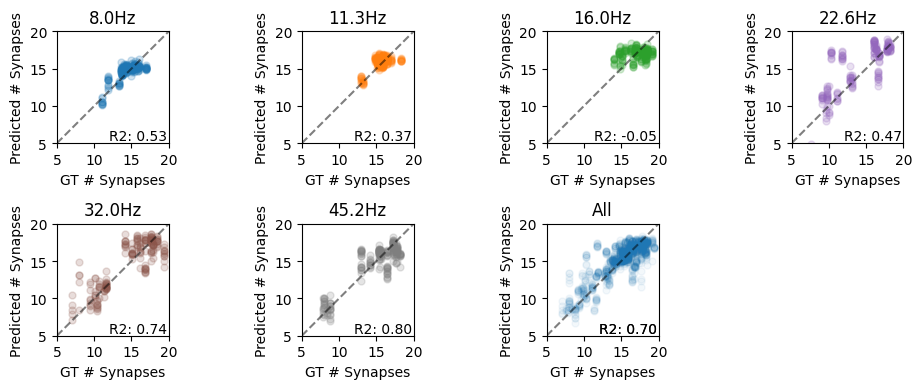

In [42]:
train_plot_result_frequency(final_clean_strained, xgb_model)

8.0Hz, 1043 samples, R2: 0.605, RMSE: 0.835
11.3Hz, 1009 samples, R2: 0.443, RMSE: 0.845
16.0Hz, 979 samples, R2: 0.041, RMSE: 1.436
22.6Hz, 953 samples, R2: 0.530, RMSE: 2.378
32.0Hz, 947 samples, R2: 0.823, RMSE: 1.742
45.2Hz, 970 samples, R2: 0.884, RMSE: 1.505
All data, 5901 samples, R2: 0.767, RMSE: 1.589


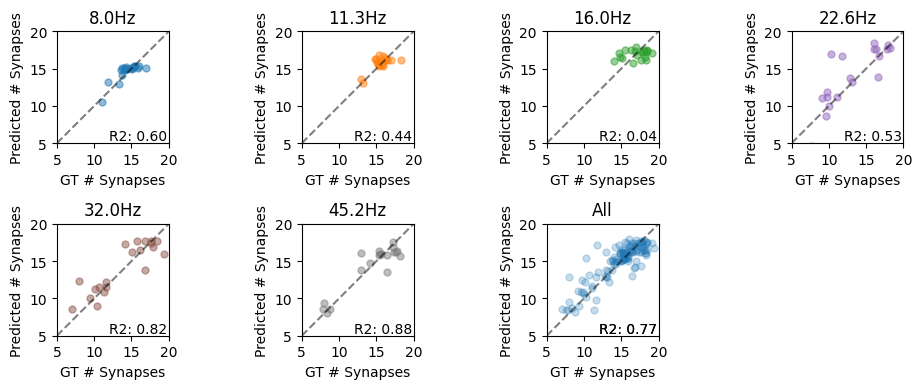

In [43]:
train_plot_result_frequency_grouped(final_clean_strained, xgb_model)

10-15 dB, 542 samples, R2: 0.196, RMSE: 1.766
20-25 dB, 870 samples, R2: 0.504, RMSE: 1.586
30-35 dB, 907 samples, R2: 0.640, RMSE: 1.424
40-45 dB, 802 samples, R2: 0.508, RMSE: 1.776
50-55 dB, 721 samples, R2: 0.568, RMSE: 1.905
60-65 dB, 719 samples, R2: 0.583, RMSE: 1.992
70-75 dB, 724 samples, R2: 0.654, RMSE: 2.177
80-85 dB, 616 samples, R2: 0.658, RMSE: 1.927
All data, 5901 samples, R2: 0.702, RMSE: 1.556


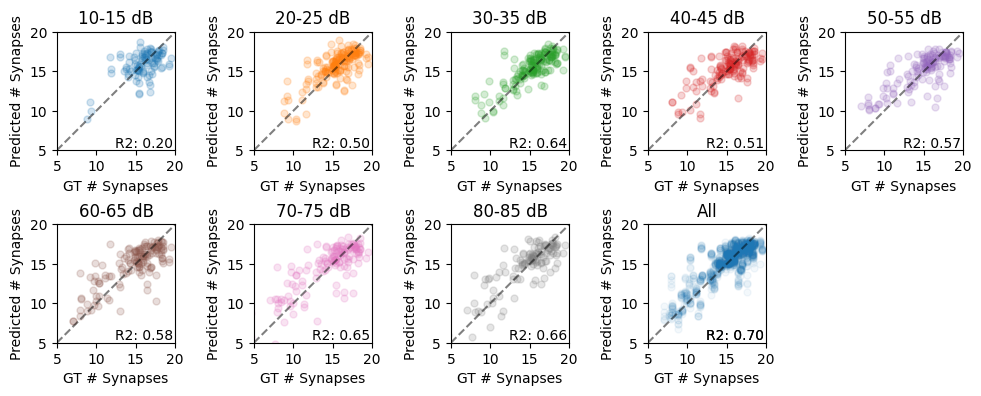

In [44]:
train_plot_result(final_clean_strained, xgb_model)

In [45]:
final_clean_strained_70 = final_clean_strained[final_clean_strained["Level(dB)"] == 70]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Time (hrs)"]

X = final_clean_strained_70[
    num_features + cat_features + log_features + minmax_features
]
y = final_clean_strained_70["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[final_clean_strained_70.DataGroup != "Test"],
    X[final_clean_strained_70.DataGroup == "Test"],
    y[final_clean_strained_70.DataGroup != "Test"],
    y[final_clean_strained_70.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
        ("minmax_scale", MinMaxScaler(), minmax_features),
    ]
)

Best RF params: {'rf__n_estimators': 150, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 'log2', 'rf__max_depth': 30}
Best RF score: 0.217, R2 on test set: 0.278
8.0Hz, 1043 samples, R2: 0.589, RMSE: 0.876
11.3Hz, 1009 samples, R2: 0.253, RMSE: 0.949
16.0Hz, 979 samples, R2: 0.038, RMSE: 1.438
22.6Hz, 953 samples, R2: 0.251, RMSE: 2.891
32.0Hz, 947 samples, R2: 0.345, RMSE: 3.016
45.2Hz, 970 samples, R2: 0.256, RMSE: 3.120
All data, 5901 samples, R2: 0.384, RMSE: 2.238


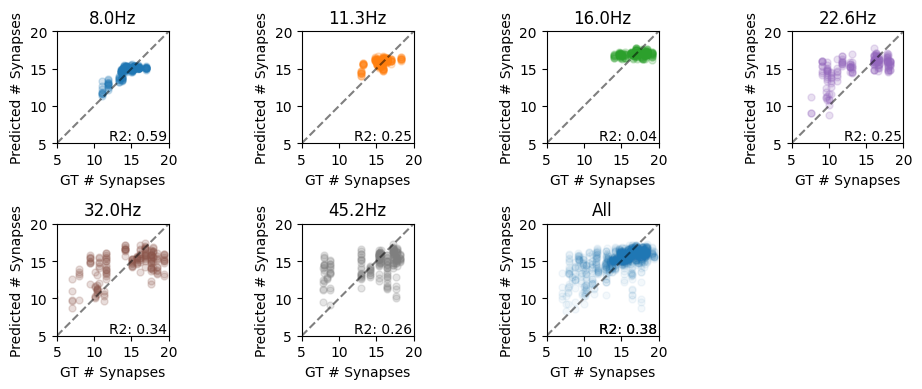

In [46]:
rf_params = {
    "rf__n_estimators": [25, 30, 50, 100, 150, 200, 300, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_
train_plot_result_frequency(final_clean_strained, best_rf_model)

8.0Hz, 1043 samples, R2: 0.627, RMSE: 0.811
11.3Hz, 1009 samples, R2: 0.268, RMSE: 0.969
16.0Hz, 979 samples, R2: 0.094, RMSE: 1.395
22.6Hz, 953 samples, R2: 0.346, RMSE: 2.807
32.0Hz, 947 samples, R2: 0.456, RMSE: 3.051
45.2Hz, 970 samples, R2: 0.435, RMSE: 3.319
All data, 5901 samples, R2: 0.501, RMSE: 2.326


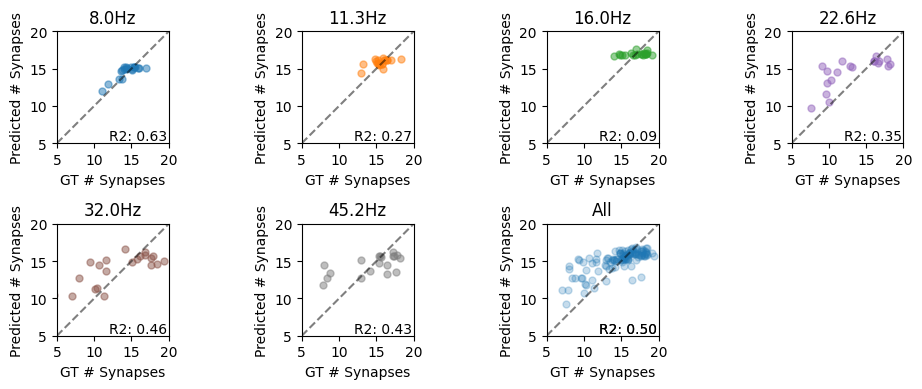

In [47]:
train_plot_result_frequency_grouped(final_clean_strained, best_rf_model)